In [1]:
import os 
import numpy as np

import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from sklearn.metrics import recall_score, f1_score
import re
from sklearn.metrics import confusion_matrix
from fastapi import FastAPI
import uvicorn

In [3]:
train_val_data_path = os.path.join("C:/Plant Diseases/archive (1)/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)")
train_data_path = os.path.join(train_val_data_path, "train")
val_data_path = os.path.join(train_val_data_path, "valid")
test_data_path = os.path.join("C:/Plant Diseases/archive (1)/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)")

# Instasiating the API
app = FastAPI()


In [4]:
classes = os.listdir(train_data_path)
classes

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___healthy',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___healthy',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___healthy',
 'Potato___Late_blight',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___healthy',
 'Strawberry___Leaf_scorch',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___healthy',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spid

In [5]:
diseases = []
NumberOfDiseases = 0
for diseases in classes:
    if diseases.split('___')[0] not in diseases:
        diseases.append(diseases.split('___')[0])
    if diseases.split('___')[1] != 'healthy':
        NumberOfDiseases += 1

In [6]:
print(f"Unique Plants are: \n{diseases}")

Unique Plants are: 
Tomato___Tomato_Yellow_Leaf_Curl_Virus


In [7]:
def show_random_smample(data_path, n_samples):
    classes = os.listdir(data_path)
    fig, ax = plt.subplots(1, n_samples, figsize=(5*n_samples, 6))
    fig.figure.figsize=(5*n_samples, 5)
    for i in range(n_samples):
        rand_class = classes[np.random.randint(0, len(classes), 1)[0]]
        rand_class_path = os.path.join(data_path, rand_class)
        samples = os.listdir(rand_class_path)
        rand_sample = np.random.randint(0, len(samples), 1)[0]
        img = cv2.imread(os.path.join(rand_class_path, samples[rand_sample]), cv2.COLOR_BGR2RGB)
        ax[i].imshow(img)
        ax[i].set_title(f"{rand_class},\n {img.shape}")
    fig.tight_layout()
    fig.suptitle("Random samples")
    fig.show()

C:\Users\sharm\AppData\Local\Temp\ipykernel_73644\313313777.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


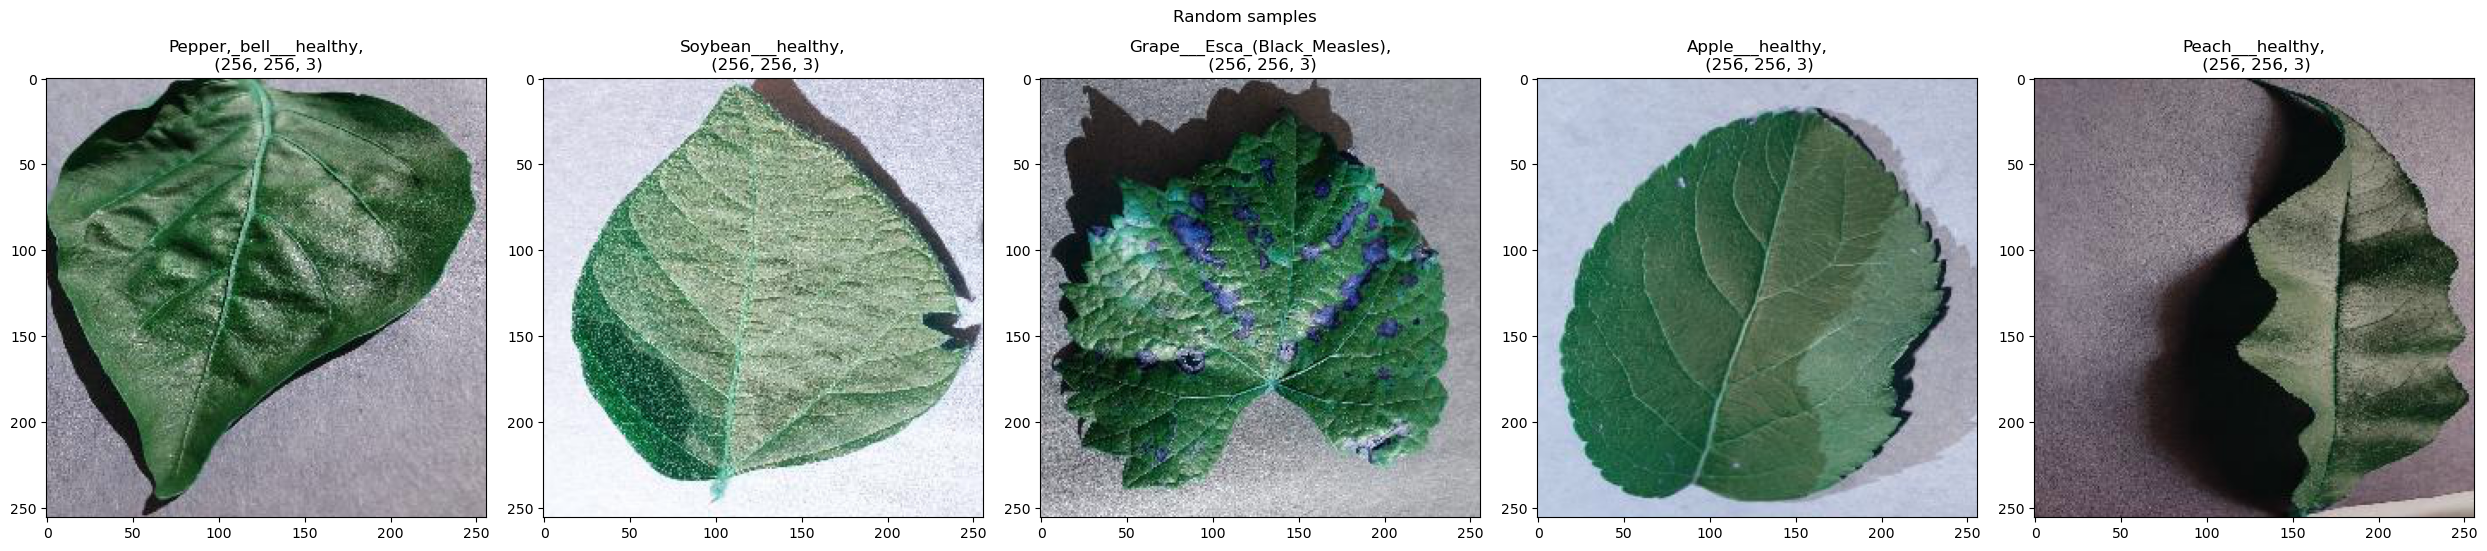

In [8]:
show_random_smample(train_data_path, n_samples=5)

In [9]:
img_height, img_width = 256, 256
batch_size = 64

# Create an ImageDataGenerator for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

# Flow data from the training directory
train_generator = train_datagen.flow_from_directory(
    train_data_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    classes = classes,
    class_mode='categorical'  # Set to 'binary' or 'categorical' based on your problem
)

# Create an ImageDataGenerator for validation data
val_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)
# Flow data from the validation directory
validation_generator = val_datagen.flow_from_directory(
    val_data_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    classes = classes,
    class_mode='categorical'
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


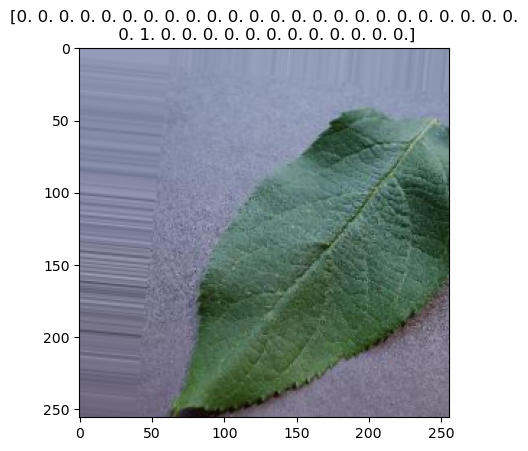

In [10]:
rand_batch = next(iter(train_generator))
plt.imshow(rand_batch[0][0])
plt.title(str(rand_batch[1][1]))
plt.show()

In [11]:
train_generator.class_indices

{'Apple___Apple_scab': 0,
 'Apple___Black_rot': 1,
 'Apple___Cedar_apple_rust': 2,
 'Apple___healthy': 3,
 'Blueberry___healthy': 4,
 'Cherry_(including_sour)___healthy': 5,
 'Cherry_(including_sour)___Powdery_mildew': 6,
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7,
 'Corn_(maize)___Common_rust_': 8,
 'Corn_(maize)___healthy': 9,
 'Corn_(maize)___Northern_Leaf_Blight': 10,
 'Grape___Black_rot': 11,
 'Grape___Esca_(Black_Measles)': 12,
 'Grape___healthy': 13,
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 14,
 'Orange___Haunglongbing_(Citrus_greening)': 15,
 'Peach___Bacterial_spot': 16,
 'Peach___healthy': 17,
 'Pepper,_bell___Bacterial_spot': 18,
 'Pepper,_bell___healthy': 19,
 'Potato___Early_blight': 20,
 'Potato___healthy': 21,
 'Potato___Late_blight': 22,
 'Raspberry___healthy': 23,
 'Soybean___healthy': 24,
 'Squash___Powdery_mildew': 25,
 'Strawberry___healthy': 26,
 'Strawberry___Leaf_scorch': 27,
 'Tomato___Bacterial_spot': 28,
 'Tomato___Early_blight': 29,
 'Toma

In [12]:
plants = set(map(lambda r: r.split('_')[0], classes))
plants

{'Apple',
 'Blueberry',
 'Cherry',
 'Corn',
 'Grape',
 'Orange',
 'Peach',
 'Pepper,',
 'Potato',
 'Raspberry',
 'Soybean',
 'Squash',
 'Strawberry',
 'Tomato'}

In [13]:
mobilenet_v2 = MobileNetV2(weights='imagenet', include_top=False)

for layer in mobilenet_v2.layers:
    layer.trainable = False

In [14]:
# Add custom layers on top of the base model
x = mobilenet_v2.output
x = GlobalAveragePooling2D()(x)  # Pooling layer
x = Dense(1024, activation='relu')(x)  # Fully connected layer
predictions = Dense(len(classes), activation='softmax')(x)  # Output layer

# Create the final model
model = tf.keras.Model(inputs=mobilenet_v2.input, outputs=predictions)

In [15]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, None, None, 3)]      0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, None, None, 32)       864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, None, None, 32)       128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, None, None, 32)       0         ['bn_Conv1[0][0]']        

In [16]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy',  # Standard metric
                       tf.keras.metrics.Recall()])

In [17]:
results = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=12,
    steps_per_epoch=500,
    verbose=1)

Epoch 1/12


500/500 [==============================] - 2011s 4s/step - loss: 0.4923 - accuracy: 0.8508 - recall: 0.8017 - val_loss: 0.2963 - val_accuracy: 0.9060 - val_recall: 0.8824
Epoch 2/12
500/500 [==============================] - 2096s 4s/step - loss: 0.2505 - accuracy: 0.9161 - recall: 0.9006 - val_loss: 0.2934 - val_accuracy: 0.9023 - val_recall: 0.8866
Epoch 3/12
500/500 [==============================] - 1957s 4s/step - loss: 0.2161 - accuracy: 0.9278 - recall: 0.9168 - val_loss: 0.2062 - val_accuracy: 0.9284 - val_recall: 0.9190
Epoch 4/12
500/500 [==============================] - 1715s 3s/step - loss: 0.1857 - accuracy: 0.9366 - recall: 0.9274 - val_loss: 0.2009 - val_accuracy: 0.9306 - val_recall: 0.9200
Epoch 5/12
500/500 [==============================] - 1665s 3s/step - loss: 0.1682 - accuracy: 0.9418 - recall: 0.9342 - val_loss: 0.1986 - val_accuracy: 0.9337 - val_recall: 0.9254
Epoch 6/12
500/500 [==============================] - 1598s 3s/step - loss: 0.1603 - acc

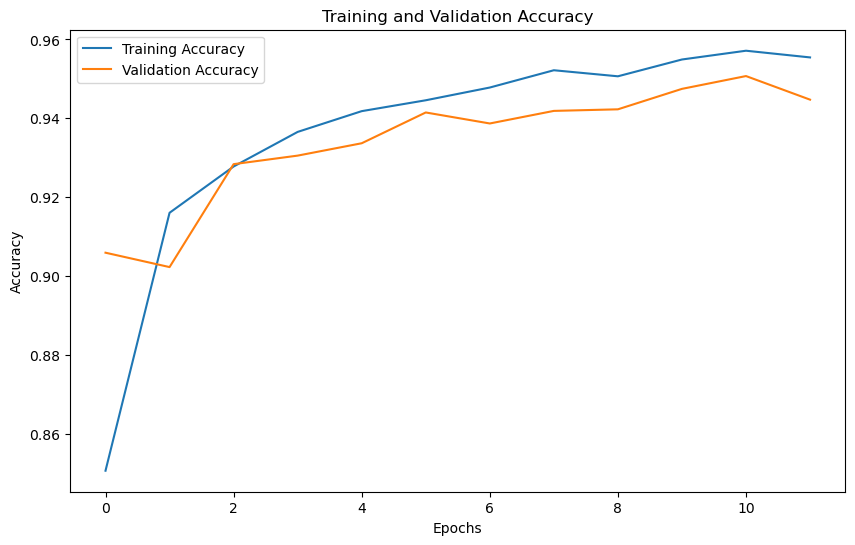

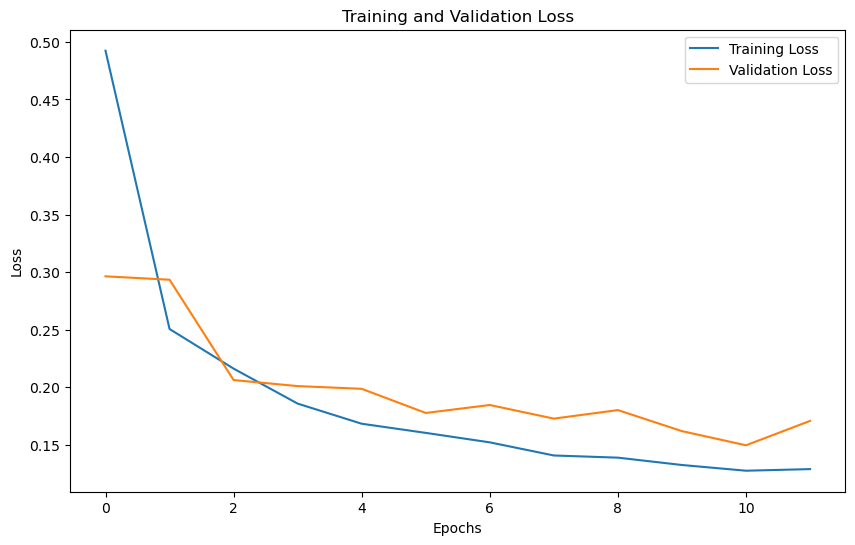

In [18]:
# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(results.history['accuracy'], label='Training Accuracy')
plt.plot(results.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(results.history['loss'], label='Training Loss')
plt.plot(results.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [19]:
len(os.listdir(test_data_path))

2

In [20]:
model.evaluate(validation_generator)

275/275 [==============================] - 528s 2s/step - loss: 0.1712 - accuracy: 0.9455 - recall: 0.9417


[0.17122139036655426, 0.945538341999054, 0.9416685700416565]

In [ ]:
#tf.keras.utils.plot_model(model, to_file='model_layers.png', show_shapes=True, show_layer_names=True)

In [21]:
os.listdir(test_data_path)

['train', 'valid']

In [22]:
# Save The Model
model.save("plant_disease_model_v3.h5")

C:\Users\sharm\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


(224, 224, 3)
(1, 224, 224, 3)


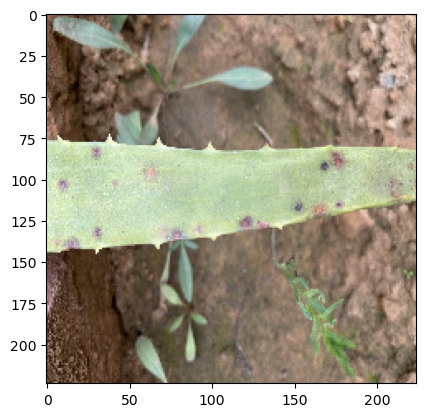

In [24]:
#getting the input
#@app.get{'/'}


# Load the test image 1
from tensorflow.keras.preprocessing import image
img_path_1 = "C:/Plant Diseases/New Image DB-20240226T231727Z-001/New Image DB/Leaf spot.jpg"
img_1 = image.load_img(img_path_1, target_size=(224, 224))

#img array
img_array_1 = image.img_to_array(img_1)
print(img_array_1.shape)

# Add batch dimension
img_array_1 = np.expand_dims(img_array_1, axis=0)

# Scale The Data
img_array_1 = img_array_1/255
print(img_array_1.shape)
plt.imshow(img_1)

(224, 224, 3)
(1, 224, 224, 3)


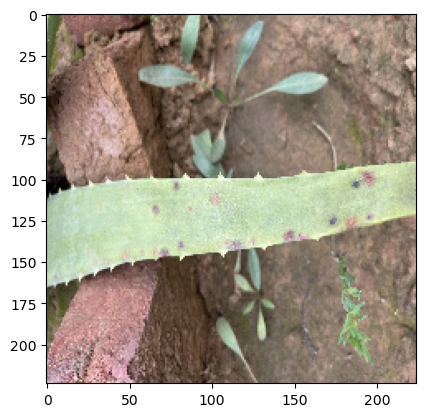

In [25]:
# Load the test image 2
from tensorflow.keras.preprocessing import image
img_path_2 = "C:/Plant Diseases/New Image DB-20240226T231727Z-001/New Image DB/Leaf spot_1.jpg"

img_2 = image.load_img(img_path_2, target_size=(224, 224))

#img arrays
img_array_2 = image.img_to_array(img_2)
print(img_array_2.shape)

# Add batch dimension
img_array_2 = np.expand_dims(img_array_2, axis=0)

# Scale The Data
img_array_2 = img_array_2/255
print(img_array_2.shape)
plt.imshow(img_2)

(224, 224, 3)
(1, 224, 224, 3)


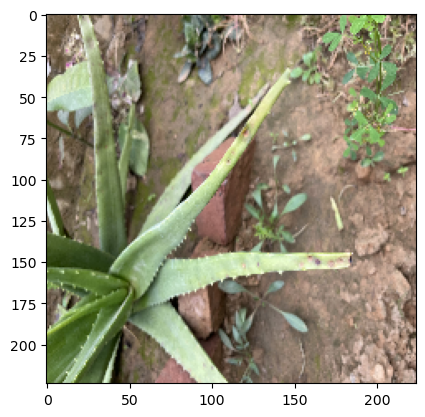

In [26]:
# Load the test image 3
from tensorflow.keras.preprocessing import image
img_path_3 = "C:/Plant Diseases/New Image DB-20240226T231727Z-001/New Image DB/Leaf spot_2.jpg"
img_3 = image.load_img(img_path_3, target_size=(224, 224))

#img arrays
img_array_3 = image.img_to_array(img_3)
print(img_array_3.shape)

# Add batch dimension
img_array_3 = np.expand_dims(img_array_3, axis=0)

# Scale The Data
img_array_3 = img_array_3/255
print(img_array_3.shape)
plt.imshow(img_3)

(224, 224, 3)
(1, 224, 224, 3)


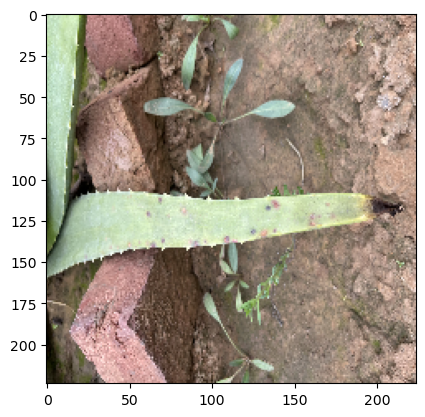

In [27]:
# Load the test image 4
from tensorflow.keras.preprocessing import image
img_path_4 = "C:/Plant Diseases/New Image DB-20240226T231727Z-001/New Image DB/Leaf spot_3.jpg"

img_4 = image.load_img(img_path_4, target_size=(224, 224))

#img arrays
img_array_4 = image.img_to_array(img_4)
print(img_array_4.shape)

# Add batch dimension
img_array_4 = np.expand_dims(img_array_4, axis=0)

# Scale The Data
img_array_4 = img_array_4/255
print(img_array_4.shape)
plt.imshow(img_4)

In [28]:
y_pred_1 = model.predict(img_array_1)
y_pred_1

1/1 [==============================] - 2s 2s/step


array([[4.2878655e-03, 2.8409647e-06, 2.7578988e-06, 1.8393477e-10,
        1.7308321e-11, 3.0494071e-08, 6.7366130e-08, 1.4599193e-05,
        5.7965843e-04, 2.0920095e-09, 9.5796133e-07, 3.3478205e-05,
        1.5094660e-07, 9.7111379e-06, 2.1241586e-10, 1.1681546e-11,
        9.9033958e-01, 3.1188922e-04, 3.7040797e-06, 2.9834330e-06,
        7.0316212e-08, 4.0085553e-07, 4.7029974e-07, 2.5515794e-09,
        1.3093708e-09, 2.3779618e-09, 5.2111393e-10, 2.5739919e-03,
        1.7913561e-07, 6.3059102e-05, 4.6639332e-07, 1.4076979e-03,
        6.7602293e-09, 3.6263137e-04, 4.5342636e-11, 6.8830076e-07,
        4.3205869e-08, 5.6173225e-13]], dtype=float32)

In [29]:
y_pred_2 = model.predict(img_array_2)
y_pred_2

1/1 [==============================] - 0s 85ms/step


array([[1.10798201e-05, 4.57203132e-04, 4.79648261e-05, 5.66679539e-08,
        3.77841813e-10, 3.79887788e-05, 2.10614061e-07, 1.26859890e-02,
        2.37182319e-01, 4.20997850e-07, 1.89082623e-02, 2.85343558e-04,
        2.35727592e-03, 1.31261540e-05, 4.11141883e-07, 4.60921190e-10,
        2.28597298e-02, 4.52307831e-05, 1.96718452e-06, 3.87269182e-07,
        8.60163425e-07, 7.41551048e-05, 1.22712745e-05, 3.94725384e-06,
        1.63588118e-06, 1.95068264e-08, 1.57214526e-08, 6.87381744e-01,
        3.62371677e-04, 3.09610809e-03, 4.64302161e-07, 1.54260278e-03,
        5.47571399e-05, 1.25158234e-02, 4.96367136e-07, 5.23826820e-05,
        5.37400683e-06, 8.26834690e-09]], dtype=float32)

In [30]:
y_pred_3 = model.predict(img_array_3)
y_pred_3

1/1 [==============================] - 0s 91ms/step


array([[2.3082635e-04, 3.2153782e-01, 7.7759153e-03, 8.1676444e-06,
        6.5664487e-08, 6.8044785e-04, 2.4188082e-06, 5.1420266e-06,
        4.4083994e-02, 3.5936459e-06, 2.3900917e-04, 1.2374606e-03,
        3.3174828e-04, 1.9959142e-04, 3.7165471e-09, 7.4655206e-09,
        2.5181723e-04, 1.1517232e-06, 7.3717551e-06, 1.6875418e-05,
        1.0972272e-05, 7.6285545e-08, 6.7380572e-09, 7.8150406e-06,
        4.9330659e-08, 6.7672390e-06, 1.1533235e-06, 6.1395782e-01,
        1.8087321e-05, 6.6524218e-03, 3.4188083e-06, 2.4472729e-03,
        8.6095548e-07, 1.3867714e-05, 2.8849370e-09, 2.6590834e-04,
        5.7565785e-08, 1.5221676e-08]], dtype=float32)

In [31]:
y_pred_4 = model.predict(img_array_4)
y_pred_4

1/1 [==============================] - 0s 89ms/step


array([[9.3057854e-05, 4.3138009e-03, 5.2465044e-02, 2.2709378e-07,
        6.3987424e-09, 8.7179025e-08, 1.3002146e-08, 1.2975882e-02,
        1.2653145e-01, 6.5650255e-07, 3.0927863e-03, 1.1584137e-05,
        4.0370444e-04, 8.7434636e-08, 1.6731573e-06, 1.0233903e-08,
        1.9205052e-02, 1.8863959e-05, 8.6366572e-06, 9.1379391e-08,
        1.4642529e-04, 5.8021828e-06, 5.3373992e-04, 3.1460477e-08,
        2.0873777e-08, 6.3997190e-09, 1.6362645e-09, 7.7440321e-01,
        1.7273831e-03, 6.1582908e-04, 1.1924924e-06, 3.1058847e-03,
        3.0937667e-07, 2.0988198e-04, 1.8586393e-06, 1.2566545e-04,
        4.9593019e-08, 4.3654120e-09]], dtype=float32)

In [32]:
# image 1
np.argmax(y_pred_1[0])

16

In [33]:
#image 2
np.argmax(y_pred_2[0])

27

In [34]:
#image 3
np.argmax(y_pred_3[0])

27

In [35]:
#image 4
np.argmax(y_pred_4[0])

27

In [36]:
diseases = []
NumberOfDiseases = 0
for diseases in classes:
    if diseases.split('___')[0] not in plants:
        plants.append(plant.split('___')[0])
    if plant.split('___')[1] != 'healthy':
        NumberOfDiseases += 1

NameError: name 'plant' is not defined

In [37]:
classes[np.argmax(y_pred_1[0])] # image 1 prediction result

'Peach___Bacterial_spot'

In [38]:
classes[np.argmax(y_pred_2[0])] # image 2 prediction result

'Strawberry___Leaf_scorch'

In [39]:
classes[np.argmax(y_pred_3[0])] # image 3 prediction result

'Strawberry___Leaf_scorch'

In [40]:
classes[np.argmax(y_pred_4[0])] # image 4 prediction result

'Strawberry___Leaf_scorch'

In [41]:
#first reponse of the user
async def get_disease():
    return {'This is': classes[np.argmax(y_pred_1[0])]}